# 📊 EDA — SRDB Soil Respiration Data (V5)

**File:** `srdb-data-V5.csv`  
**Rows:** 10,366 | **Columns:** 85  
**Description:** Global soil respiration database with measurements, environmental variables, carbon fluxes, and ecosystem metadata. **Heavy missing data** (543,349 missing values).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Load Data


In [2]:
from pathlib import Path
raw = Path('../data/raw')
df = pd.read_csv(raw / 'srdb-data-V5.csv', low_memory=False)
print(f"Shape: {df.shape}")
df.head()


Shape: (10366, 85)


,Record_number,Entry_date,Study_number,Author,Duplicate_record,Quality_flag,Contributor,Country,Region,Site_name,...,BA,C_veg_total,C_AG,C_BG,C_CR,C_FR,C_litter,C_soilmineral,C_soildepth,Notes
0,1.0,2008-09-26,2534,Bond-Lamberty,NaN,Q02,BBL,Canada,Manitoba,BOREAS NSA-D1998,...,0.0,200.0,80.0,120.0,70.0,50.0,NaN,41800.0,70.0,LAI from Bond-Lamberty (2002); C from Wang (20...
1,2.0,2008-09-26,2534,Bond-Lamberty,NaN,Q02,BBL,Canada,Manitoba,BOREAS NSA-D1995,...,0.5,160.0,90.0,70.0,40.0,30.0,NaN,41800.0,70.0,LAI from Bond-Lamberty (2002); C from Wang (20...
2,3.0,2008-09-26,2534,Bond-Lamberty,NaN,Q02,BBL,Canada,Manitoba,BOREAS NSA-D1989,...,0.0,520.0,400.0,120.0,70.0,50.0,NaN,41800.0,70.0,LAI from Bond-Lamberty (2002); C from Wang (20...
3,4.0,2008-09-26,2534,Bond-Lamberty,NaN,Q02,BBL,Canada,Manitoba,BOREAS NSA-D1981,...,4.1,1050.0,700.0,350.0,230.0,120.0,NaN,41800.0,70.0,LAI from Bond-Lamberty (2002); C from Wang (20...
4,5.0,2008-09-26,2534,Bond-Lamberty,NaN,Q02,BBL,Canada,Manitoba,BOREAS NSA-D1964,...,11.6,2300.0,1500.0,800.0,600.0,200.0,NaN,41800.0,70.0,LAI from Bond-Lamberty (2002); C from Wang (20...


## 2. Basic Information


In [3]:
df.info(verbose=True, show_counts=True, max_cols=None)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10366 entries, 0 to 10365
Data columns (total 85 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Record_number       10366 non-null  float64
 1   Entry_date          10366 non-null  object 
 2   Study_number        10366 non-null  int64  
 3   Author              10364 non-null  object 
 4   Duplicate_record    88 non-null     object 
 5   Quality_flag        2424 non-null   object 
 6   Contributor         10366 non-null  object 
 7   Country             10355 non-null  object 
 8   Region              7561 non-null   object 
 9   Site_name           8960 non-null   object 
 10  Site_ID             10366 non-null  object 
 11  Study_midyear       10183 non-null  float64
 12  YearsOfData         10184 non-null  float64
 13  Latitude            9985 non-null   float64
 14  Longitude           9983 non-null   float64
 15  Elevation           5814 non-null   float64
 16  Mani

In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Record_number,10366.0,NaN,NaN,NaN,5218.003695,3007.267164,1.0,2612.25,5216.5,7828.75,10429.0
Entry_date,10366,554,2020-03-15,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Study_number,10366.0,NaN,NaN,NaN,6666.983504,3464.050452,14.0,3795.0,6617.0,10069.0,12000.0
Author,10364,1172,Wang,366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duplicate_record,88,38,3905,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
C_FR,811.0,NaN,NaN,NaN,316.216348,1033.249763,0.0016,83.25,158.29,269.0,16350.0
C_litter,560.0,NaN,NaN,NaN,1380.462625,2510.927737,0.0,282.5,610.0,1354.0,32875.0
C_soilmineral,1099.0,NaN,NaN,NaN,13648.587252,32789.880243,70.0,3600.0,6560.0,11850.0,426000.0
C_soildepth,705.0,NaN,NaN,NaN,37.333333,30.234046,1.0,15.0,30.0,50.0,150.0


## 3. Missing Values Analysis

This dataset has extensive missingness — critical to understand patterns.


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
missing_df = missing_df.sort_values('Percent', ascending=False)

print(f"Total missing values: {missing.sum():,}")
print(f"Columns with >50% missing: {(missing_pct > 50).sum()}")
print(f"Columns with 0% missing: {(missing_pct == 0).sum()}")
print(f"\nMissing values per column:\n")
print(missing_df.to_string())


Total missing values: 543,349
Columns with >50% missing: 55
Columns with 0% missing: 5

Missing values per column:

                    Count  Percent
Duplicate_record    10278    99.15
Rs_autumn           10262    99.00
Rs_spring           10260    98.98
Ndep                10236    98.75
Rootlitter_flux     10221    98.60
TBCA                10216    98.55
TotDet_flux         10202    98.42
Rs_dry              10166    98.07
Rlitter_annual      10161    98.02
NPP_FR              10129    97.71
Rs_wet              10121    97.64
RC_season           10107    97.50
RC_seasonal         10099    97.42
Rs_summer           10046    96.91
Rs_winter           10045    96.90
C_veg_total          9975    96.23
GPP                  9962    96.10
C_CR                 9945    95.94
BNPP                 9940    95.89
ER                   9909    95.59
PET                  9814    94.67
C_litter             9806    94.60
C_BG                 9802    94.56
NPP                  9694    93.52
ANPP     

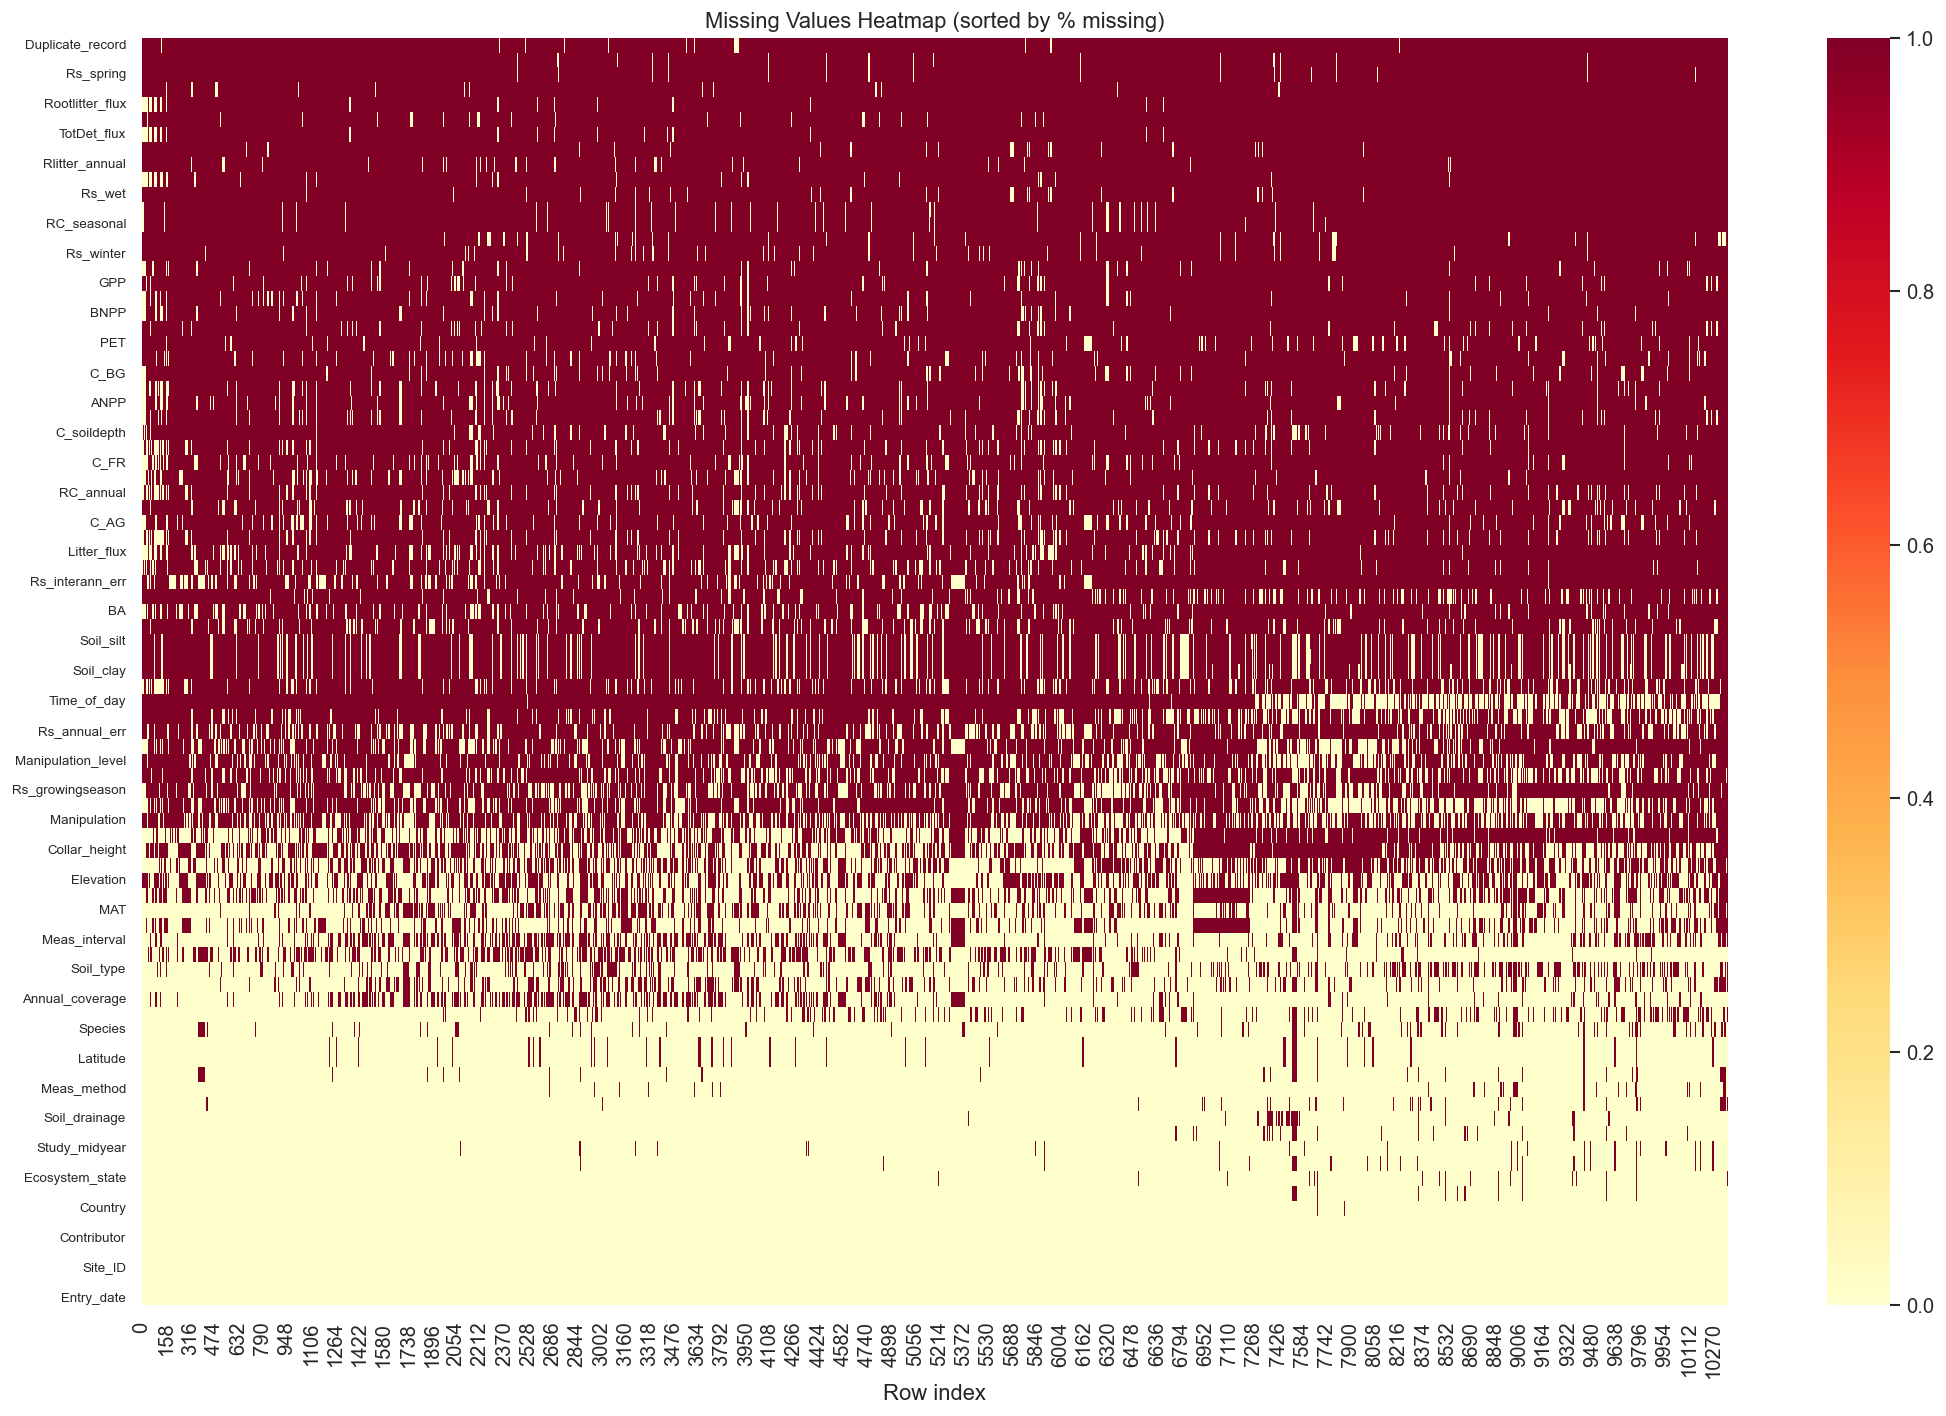

In [15]:
# Missing values heatmap (columns sorted by missingness)
cols_by_missing = missing_df.index.tolist()
fig, ax = plt.subplots(figsize=(18, 12))
sns.heatmap(df[cols_by_missing].isnull().T, cbar=True, cmap='YlOrRd', ax=ax,
            yticklabels=2)
ax.set_title('Missing Values Heatmap (sorted by % missing)')
ax.set_xlabel('Row index')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()


In [7]:
# Categorise columns by missingness severity
low = missing_pct[(missing_pct > 0) & (missing_pct <= 20)].index.tolist()
medium = missing_pct[(missing_pct > 20) & (missing_pct <= 50)].index.tolist()
high = missing_pct[(missing_pct > 50) & (missing_pct <= 80)].index.tolist()
extreme = missing_pct[missing_pct > 80].index.tolist()

print(f"Low missing (0-20%):      {len(low)} columns")
print(f"Medium missing (20-50%):  {len(medium)} columns")
print(f"High missing (50-80%):    {len(high)} columns")
print(f"Extreme missing (>80%):   {len(extreme)} columns")
print(f"\nExtreme missing columns: {extreme}")


Low missing (0-20%):      15 columns
Medium missing (20-50%):  10 columns
High missing (50-80%):    10 columns
Extreme missing (>80%):   45 columns

Extreme missing columns: ['Duplicate_record', 'Age_ecosystem', 'Soil_sand', 'Soil_silt', 'Soil_clay', 'PET', 'Study_temp', 'Study_precip', 'Time_of_day', 'Partition_method', 'Rs_interann_err', 'Rlitter_annual', 'Ra_annual', 'Rh_annual', 'RC_annual', 'Rs_spring', 'Rs_summer', 'Rs_autumn', 'Rs_winter', 'Rs_wet', 'Rs_dry', 'RC_seasonal', 'RC_season', 'GPP', 'ER', 'NEP', 'NPP', 'ANPP', 'BNPP', 'NPP_FR', 'TBCA', 'Litter_flux', 'Rootlitter_flux', 'TotDet_flux', 'Ndep', 'LAI', 'BA', 'C_veg_total', 'C_AG', 'C_BG', 'C_CR', 'C_FR', 'C_litter', 'C_soilmineral', 'C_soildepth']


## 4. Key Variable Analysis


### 4.1 Geographic Coverage


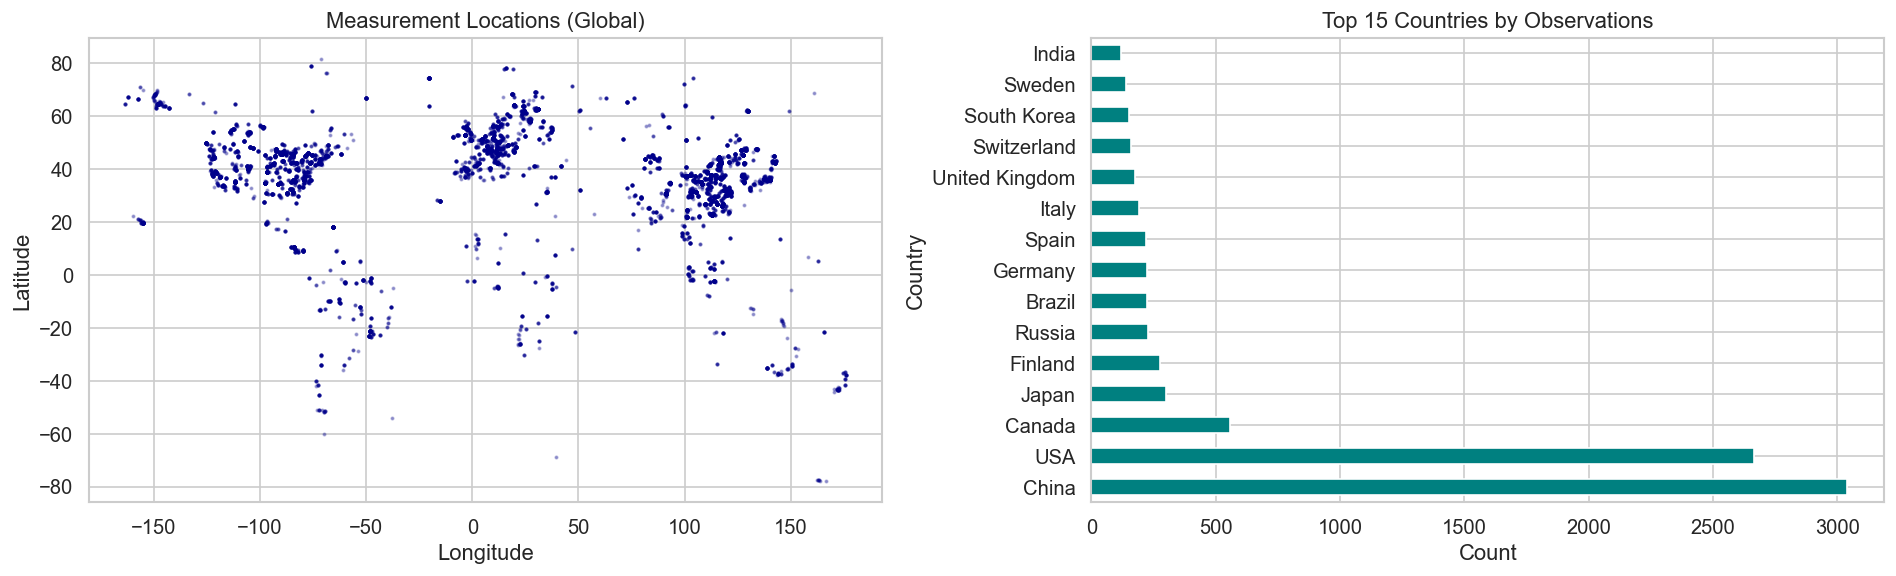

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(df['Longitude'], df['Latitude'], s=2, alpha=0.3, c='darkblue')
axes[0].set_title('Measurement Locations (Global)')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

# Country distribution
top_countries = df['Country'].value_counts().head(15)
top_countries.plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top 15 Countries by Observations')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()


### 4.2 Ecosystem & Biome Distribution


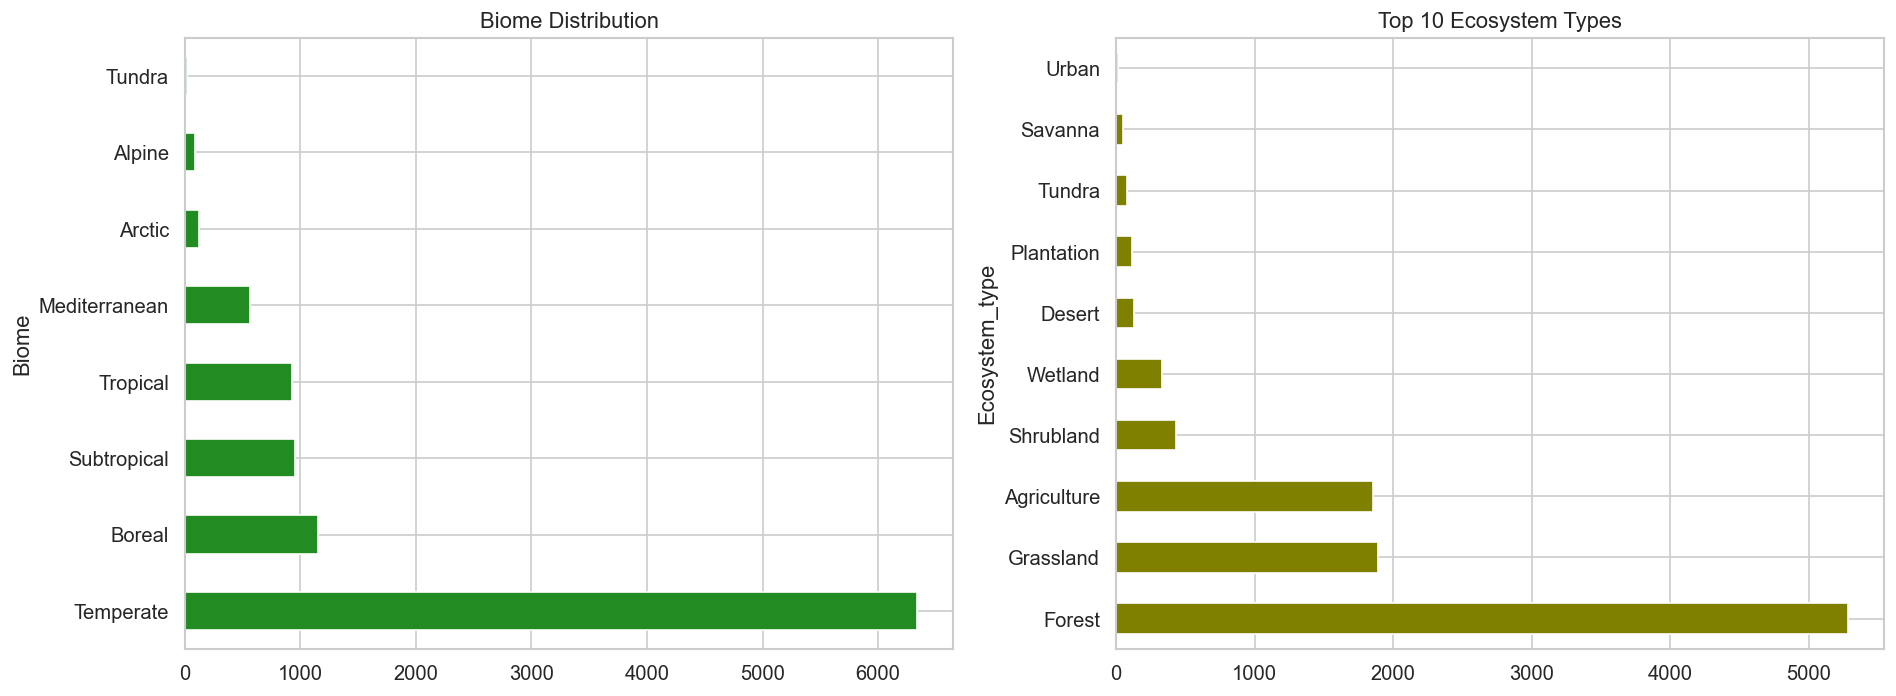

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df['Biome'].value_counts().plot(kind='barh', ax=axes[0], color='forestgreen')
axes[0].set_title('Biome Distribution')

df['Ecosystem_type'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='olive')
axes[1].set_title('Top 10 Ecosystem Types')

plt.tight_layout()
plt.show()


### 4.3 Soil Respiration (Rs_annual)


Rs_annual — 5741 non-null values (55.4%)
count     5741.000000
mean       854.551351
std        700.144141
min       -200.000000
25%        471.000000
50%        732.000000
75%       1075.000000
max      23046.000000
Name: Rs_annual, dtype: float64


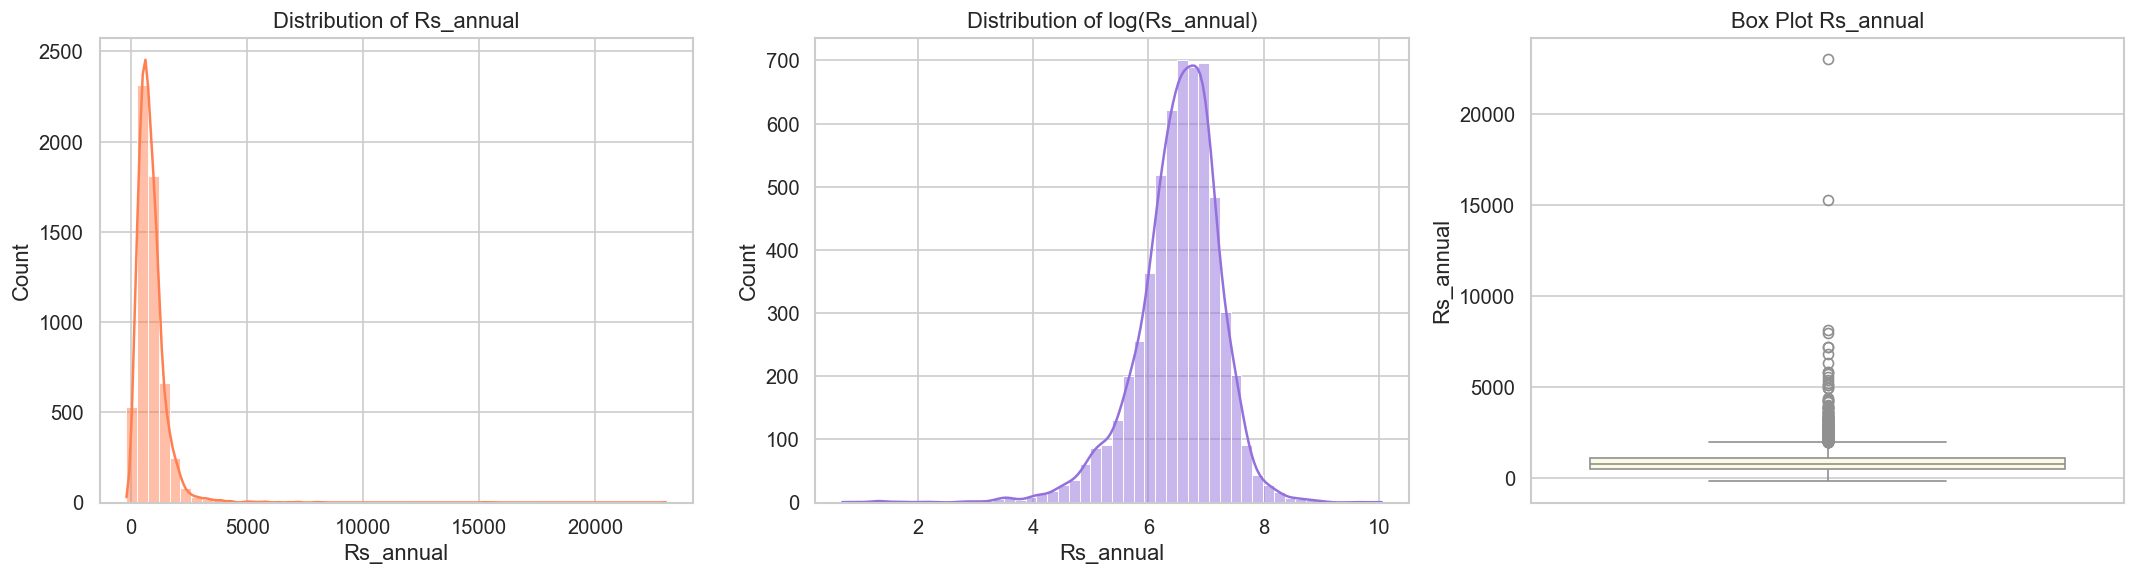

In [10]:
rs = df['Rs_annual'].dropna()
print(f"Rs_annual — {len(rs)} non-null values ({len(rs)/len(df)*100:.1f}%)")
print(rs.describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rs, bins=50, ax=axes[0], color='coral', kde=True)
axes[0].set_title('Distribution of Rs_annual')

sns.histplot(np.log1p(rs), bins=50, ax=axes[1], color='mediumpurple', kde=True)
axes[1].set_title('Distribution of log(Rs_annual)')

sns.boxplot(y=rs, ax=axes[2], color='lightyellow')
axes[2].set_title('Box Plot Rs_annual')

plt.tight_layout()
plt.show()


### 4.4 Climate Variables


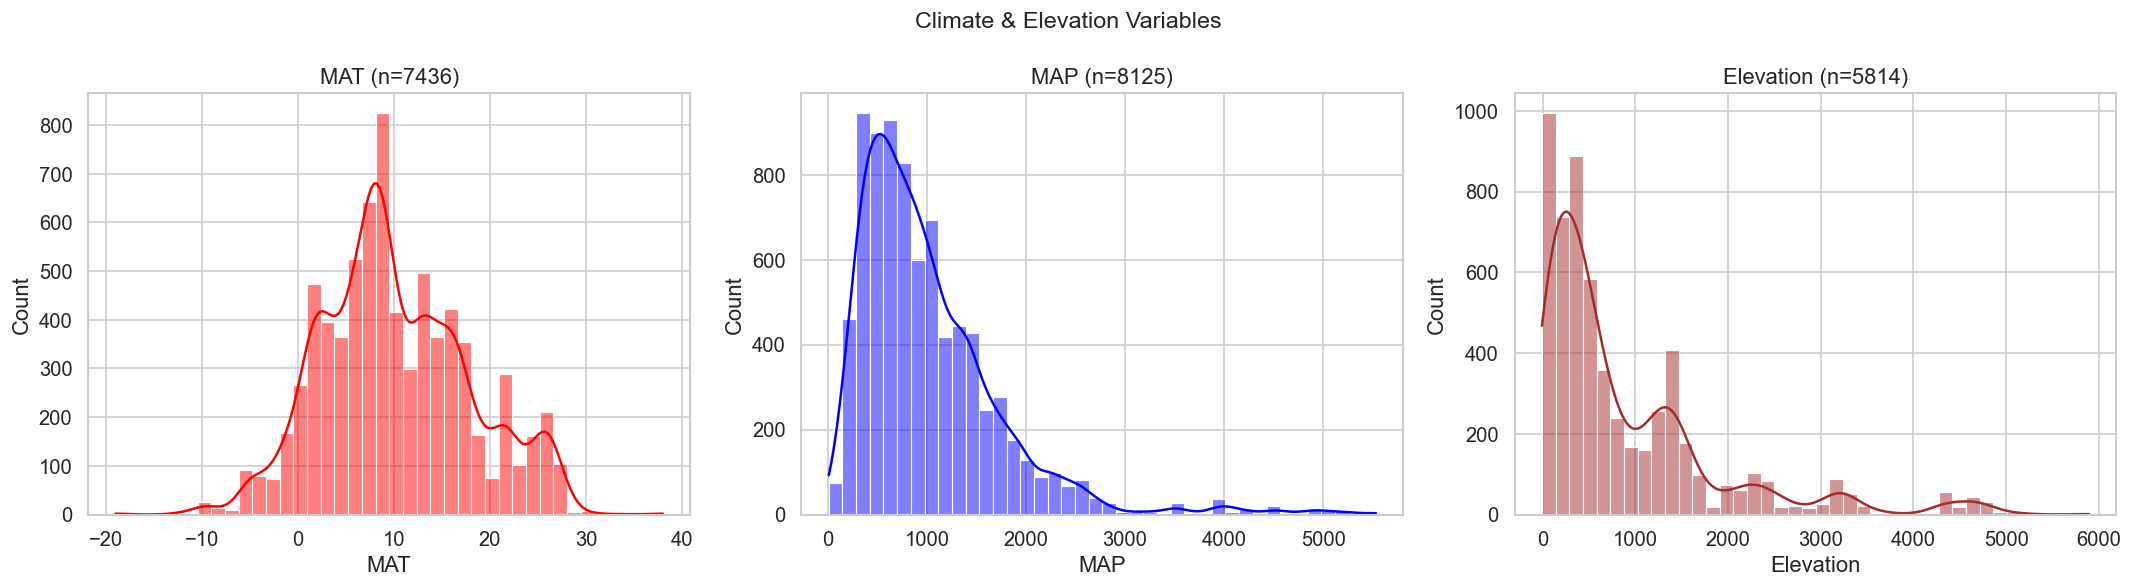

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (col, color) in enumerate([('MAT', 'red'), ('MAP', 'blue'), ('Elevation', 'brown')]):
    data = df[col].dropna()
    sns.histplot(data, bins=40, ax=axes[i], color=color, kde=True)
    axes[i].set_title(f'{col} (n={len(data)})')

plt.suptitle('Climate & Elevation Variables', fontsize=14)
plt.tight_layout()
plt.show()


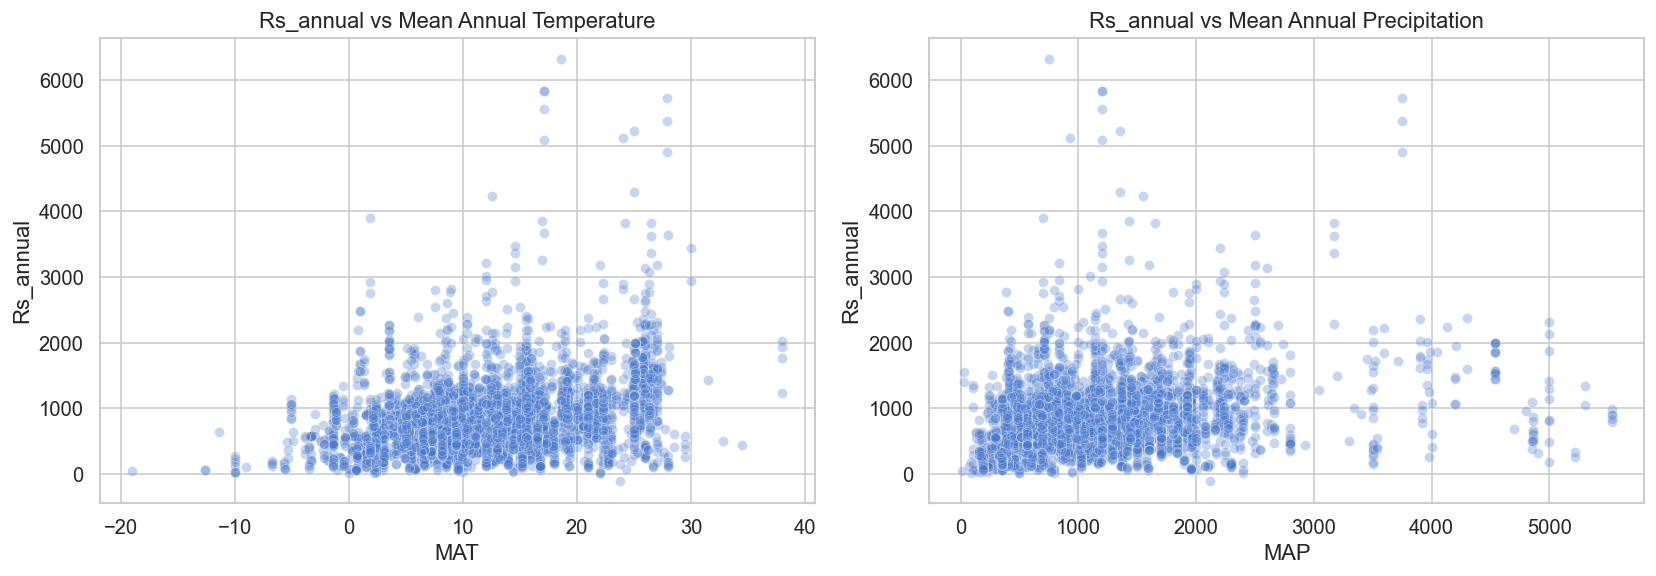

In [12]:
# Rs_annual vs MAT and MAP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mask = df[['Rs_annual', 'MAT', 'MAP']].notna().all(axis=1)
subset = df[mask]

sns.scatterplot(data=subset, x='MAT', y='Rs_annual', alpha=0.3, ax=axes[0])
axes[0].set_title('Rs_annual vs Mean Annual Temperature')

sns.scatterplot(data=subset, x='MAP', y='Rs_annual', alpha=0.3, ax=axes[1])
axes[1].set_title('Rs_annual vs Mean Annual Precipitation')

plt.tight_layout()
plt.show()


## 5. Correlation Analysis (Complete Cases)


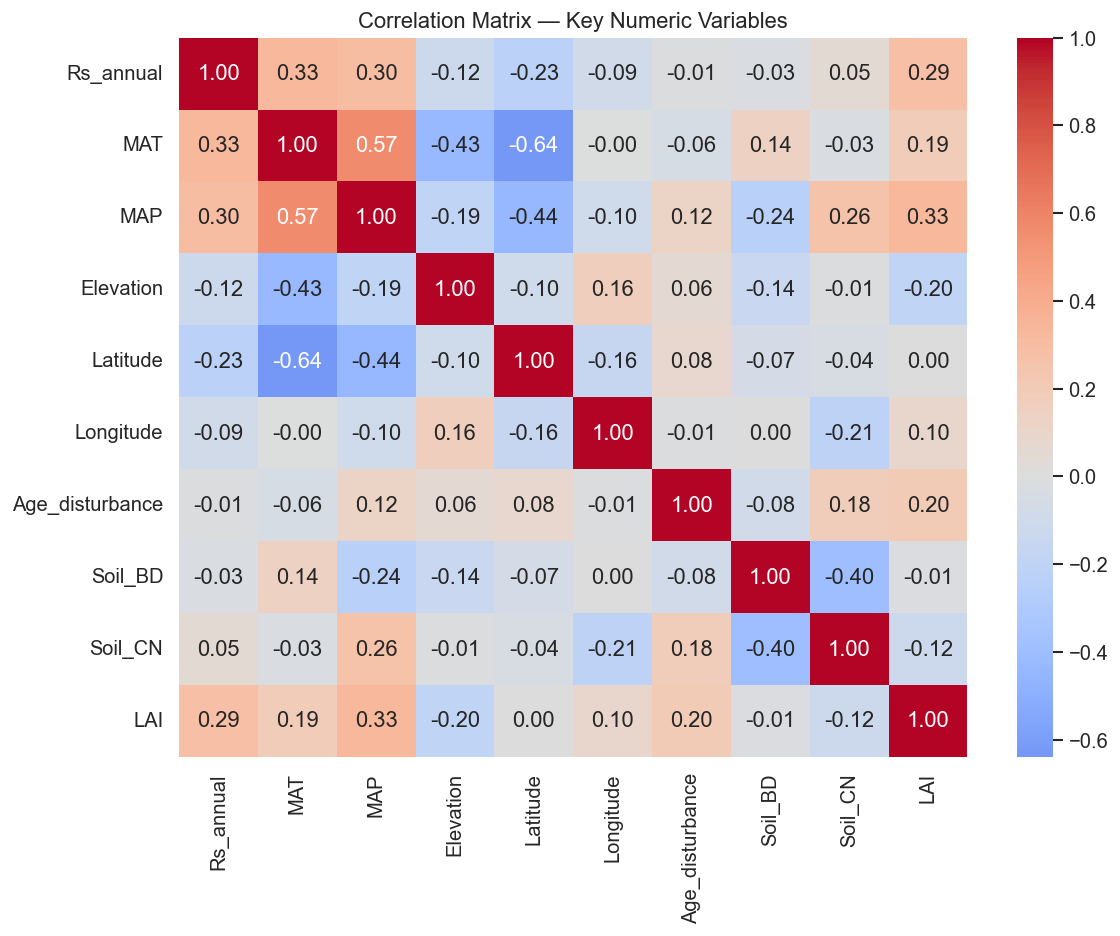

In [13]:
key_numeric = ['Rs_annual', 'MAT', 'MAP', 'Elevation', 'Latitude', 'Longitude',
                'Age_disturbance', 'Soil_BD', 'Soil_CN', 'LAI']
available = [c for c in key_numeric if c in df.columns]
corr = df[available].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix — Key Numeric Variables')
plt.tight_layout()
plt.show()


## 6. Temporal Coverage


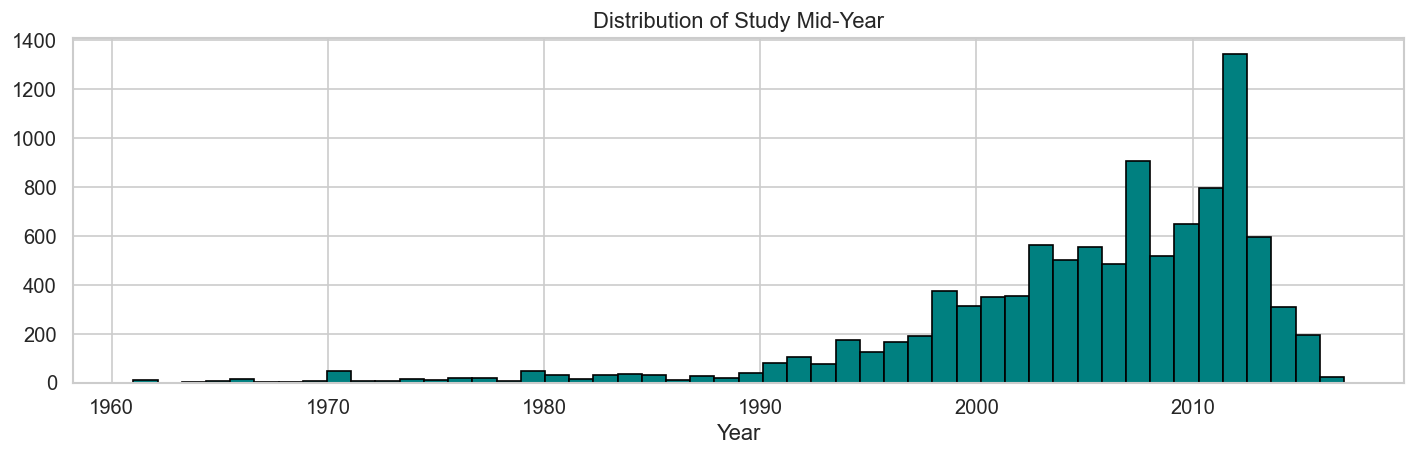

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
df['Study_midyear'].dropna().hist(bins=50, ax=ax, color='teal', edgecolor='black')
ax.set_title('Distribution of Study Mid-Year')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()


## 7. Key Findings & Summary

### Dataset Summary
- **10,366 rows × 85 columns** — **543,349 total missing values**
- Mix of measurement data, ecosystem metadata, carbon flux variables, and climate variables
- Primary variable: `Rs_annual` (annual soil respiration) — available for ~55% of records

### Key Observations
1. **Severe missingness**: Many carbon flux columns (GPP, ER, NEP, NPP, TBCA) have >90% missing data
2. **Geographic bias**: Data is concentrated in North America and Europe
3. **Temporal span**: Studies from ~1960s to 2020s, with most data post-2000
4. **Right-skewed target**: Rs_annual is right-skewed; recommend log-transforming inside the final ML models\n5. **Climate relationships**: Rs_annual shows relationships with MAT and MAP

### Action Plan
- Drop columns with >80% missing for most modelling tasks
- Impute MAT/MAP/Elevation from Lat/Lon using external climate datasets
- Consider `Biome` and `Ecosystem_type` as key grouping variables
- Log-transform Rs_annual natively inside the final regression scripts (keeping the CSV export readable for humans).
